# Graph-Level Weisfeiler-Lehman: Comparing Database Graphs

This notebook demonstrates a minimal use of **graph-level Weisfeiler-Lehman (WL) hashes**.

We build three small e-commerce databases with the familiar schema:

- `users`
- `items`
- `purchases`

Each database is converted into a heterogeneous graph. Then we compute one **graph-level WL hash** using three iterations.

## What We Want to Test

Two graphs are **isomorphic** if they have the same structure after renaming node IDs, while preserving node labels.

In this example:

- Node labels are only `User`, `Purchase`, and `Item`.
- IDs such as `user_id=1` or `item_id=10` are not part of the WL label.
- We do not use edge labels.

We compare three database graphs:

- **Graph A:** a path-like purchase graph.
- **Graph B:** the same graph as A, but with different row IDs and shuffled rows.
- **Graph C:** same table sizes as A and B, but a different branching structure.

WL gives a graph fingerprint:

- Equal hash: WL sees the graphs as the same, so they are candidate-isomorphic.
- Different hash: WL proves the graphs are not isomorphic as labeled graphs.

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import networkx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

## 2. Create Three Small Relational Databases

All three databases have:

- 3 users
- 4 items
- 6 purchases

Graphs A and B have the same path structure:

`item -- user -- item -- user -- item -- user -- item`

Graph C has a different branching structure: all users share one central item and each user also buys one private item.

In [2]:
def make_database(name, user_ids, item_ids, purchase_pairs):
    users = pd.DataFrame({
        "user_id": user_ids,
        "country": ["IL", "US", "UK"],
    })

    items = pd.DataFrame({
        "item_id": item_ids,
        "category": ["General"] * len(item_ids),
    })

    purchases = pd.DataFrame([
        {"purchase_id": purchase_id, "user_id": user_id, "item_id": item_id}
        for purchase_id, (user_id, item_id) in enumerate(purchase_pairs, start=1)
    ])

    return {"name": name, "users": users, "items": items, "purchases": purchases}


# A: path-like compact user-item graph.
A = make_database(
    name="A",
    user_ids=[1, 2, 3],
    item_ids=[10, 20, 30, 40],
    purchase_pairs=[
        (1, 10), (1, 20),
        (2, 20), (2, 30),
        (3, 30), (3, 40),
    ],
)

# B: same structure as A, with different IDs and shuffled rows.
B = make_database(
    name="B",
    user_ids=[101, 102, 103],
    item_ids=[910, 920, 930, 940],
    purchase_pairs=[
        (101, 910), (101, 920),
        (102, 920), (102, 930),
        (103, 930), (103, 940),
    ],
)
B["users"] = B["users"].sample(frac=1, random_state=1).reset_index(drop=True)
B["items"] = B["items"].sample(frac=1, random_state=2).reset_index(drop=True)
B["purchases"] = B["purchases"].sample(frac=1, random_state=3).reset_index(drop=True)

# C: same table sizes, but different structure: one shared central item.
C = make_database(
    name="C",
    user_ids=[11, 12, 13],
    item_ids=[110, 120, 130, 140],
    purchase_pairs=[
        (11, 110), (11, 120),
        (12, 110), (12, 130),
        (13, 110), (13, 140),
    ],
)

display(A["users"])
display(A["items"])
display(A["purchases"])

,user_id,country
0,1,IL
1,2,US
2,3,UK


,item_id,category
0,10,General
1,20,General
2,30,General
3,40,General


,purchase_id,user_id,item_id
0,1,1,10
1,2,1,20
2,3,2,20
3,4,2,30
4,5,3,30
5,6,3,40


## 3. Convert Tables to a Heterogeneous Graph

Tuple-level conversion:

- Each user row becomes a `User` node.
- Each item row becomes an `Item` node.
- Each purchase row becomes a `Purchase` node.
- Foreign keys become edges.

The WL labels intentionally ignore row IDs. This lets WL compare structure rather than names.

In [3]:
def database_to_graph(db):
    G = nx.Graph(name=db["name"])

    for _, row in db["users"].iterrows():
        G.add_node(("User", int(row["user_id"])), wl_label="User")

    for _, row in db["items"].iterrows():
        G.add_node(("Item", int(row["item_id"])), wl_label="Item")

    for _, row in db["purchases"].iterrows():
        purchase_node = ("Purchase", int(row["purchase_id"]))
        user_node = ("User", int(row["user_id"]))
        item_node = ("Item", int(row["item_id"]))

        G.add_node(purchase_node, wl_label="Purchase")
        G.add_edge(purchase_node, user_node)
        G.add_edge(purchase_node, item_node)

    return G


GA = database_to_graph(A)
GB = database_to_graph(B)
GC = database_to_graph(C)

for G in [GA, GB, GC]:
    print(G.graph["name"], G)

A Graph named 'A' with 13 nodes and 12 edges
B Graph named 'B' with 13 nodes and 12 edges
C Graph named 'C' with 13 nodes and 12 edges


## 4. A Sanity Check: Table Sizes Are Identical

A, B, and C have the same number of users, items, and purchases.

The difference is not table size. The difference is the **connection pattern**.

In [4]:
def database_summary(db):
    return {
        "graph": db["name"],
        "n_users": len(db["users"]),
        "n_items": len(db["items"]),
        "n_purchases": len(db["purchases"]),
    }

pd.DataFrame([database_summary(A), database_summary(B), database_summary(C)])

,graph,n_users,n_items,n_purchases
0,A,3,4,6
1,B,3,4,6
2,C,3,4,6


## 5. Visualize the Compact User-Item Graphs

For readability, we draw direct user-item purchase edges.

The actual WL computation below uses the full tuple-level graph with purchase nodes.

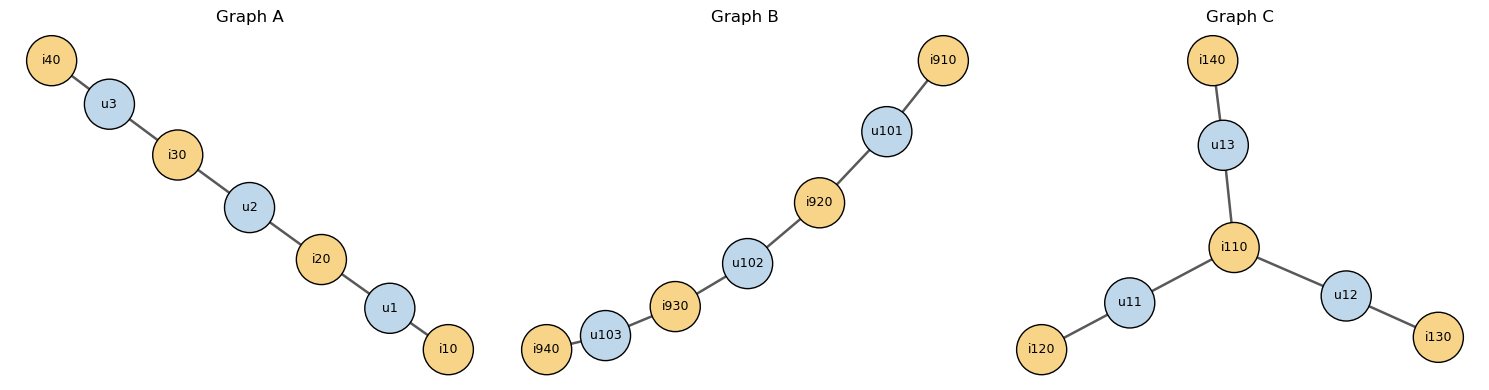

In [5]:
def compact_user_item_graph(db):
    H = nx.Graph(name=db["name"])

    for user_id in db["users"]["user_id"]:
        H.add_node(f"u{user_id}", kind="User")

    for item_id in db["items"]["item_id"]:
        H.add_node(f"i{item_id}", kind="Item")

    for _, row in db["purchases"].iterrows():
        H.add_edge(f"u{row['user_id']}", f"i{row['item_id']}")

    return H


def draw_compact(db, ax):
    H = compact_user_item_graph(db)
    pos = nx.spring_layout(H, seed=4)

    node_colors = ["#BFD7EA" if H.nodes[n]["kind"] == "User" else "#F7D488" for n in H.nodes]

    nx.draw_networkx_edges(H, pos, ax=ax, width=1.8, alpha=0.65)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors, node_size=1300, edgecolors="black")
    nx.draw_networkx_labels(H, pos, ax=ax, font_size=9)
    ax.set_title(f"Graph {db['name']}")
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for db, ax in zip([A, B, C], axes):
    draw_compact(db, ax)
plt.tight_layout()
plt.show()

## 6. Compute Graph-Level WL Hashes

We use exactly **three WL iterations**.

Intuition: WL repeatedly refines node colors using the multiset of neighboring colors. After three rounds, the graph-level hash summarizes enough local structure to distinguish the path-like graphs A/B from the branching graph C.

In [ ]:
def wl_hash(graph):
    return networkx.algorithms.graph_hashing.weisfeiler_lehman_graph_hash(
        graph,
        node_attr="wl_label",   # node labels: User, Purchase, Item
        iterations=3,
    )

wl_hash_table = pd.DataFrame([
    {"graph": graph.graph["name"], "wl_hash_prefix": wl_hash(graph)}
    for graph in [GA, GB, GC]
])

wl_hash_table

,graph,wl_hash_prefix
0,A,ec505c723f24
1,B,ec505c723f24
2,C,f55583ff01dc


## 7. Use WL Hashes as an Isomorphism Test

For this demo we use the graph-level WL hash as the comparison feature.

Interpretation:

- Equal hash: WL sees the graphs as the same; they are candidate-isomorphic.
- Different hash: WL proves the graphs are not isomorphic as labeled graphs.

A and B are the same graph under ID renaming. C is not: it has a different branching pattern.

In [7]:
def compare_with_graph_level_wl(left_name, left_graph, right_name, right_graph):
    left_hash = wl_hash(left_graph)
    right_hash = wl_hash(right_graph)

    if left_hash == right_hash:
        conclusion = "same WL hash: candidate-isomorphic"
    else:
        conclusion = "different WL hashes: definitely not isomorphic"

    return {
        "pair": f"{left_name} vs {right_name}",
        "left_hash_prefix": left_hash[:12],
        "right_hash_prefix": right_hash[:12],
        "wl_conclusion": conclusion,
    }

pd.DataFrame([
    compare_with_graph_level_wl("A", GA, "B", GB),
    compare_with_graph_level_wl("A", GA, "C", GC),
])

,pair,left_hash_prefix,right_hash_prefix,wl_conclusion
0,A vs B,ec505c723f24,ec505c723f24,same WL hash: candidate-isomorphic
1,A vs C,ec505c723f24,f55583ff01dc,different WL hashes: definitely not isomorphic


## Takeaway

Graph-level WL gives a compact fingerprint of the entire labeled graph.

In this example, WL ignores arbitrary database IDs, so A and B match. It separates C because C has a different connection pattern, even though it has the same number of users, items, and purchases.